In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
import kagglehub

path = kagglehub.dataset_download(
    "paramaggarwal/fashion-product-images-small"
)

print(path)

Using Colab cache for faster access to the 'fashion-product-images-small' dataset.
/kaggle/input/fashion-product-images-small


In [3]:
import os

for root,dirs,files in os.walk(path):
    print(root, len(files))
    break

/kaggle/input/fashion-product-images-small 1


In [4]:
csv_path = path + "/styles.csv"

df = pd.read_csv(csv_path, on_bad_lines='skip')

df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [5]:
df.shape

(44424, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  object 
 2   masterCategory      44424 non-null  object 
 3   subCategory         44424 non-null  object 
 4   articleType         44424 non-null  object 
 5   baseColour          44409 non-null  object 
 6   season              44403 non-null  object 
 7   year                44423 non-null  float64
 8   usage               44107 non-null  object 
 9   productDisplayName  44417 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 3.4+ MB


In [7]:
df.describe(include="all")

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
count,44424.000000,44424,44424,44424,44424,44409,44403,44423.000000,44107,44417
unique,NaN,5,7,45,143,46,4,NaN,8,31121
top,NaN,Men,Apparel,Topwear,Tshirts,Black,Summer,NaN,Casual,Lucera Women Silver Earrings
freq,NaN,22147,21397,15402,7067,9728,21472,NaN,34406,82
mean,29696.334301,NaN,NaN,NaN,NaN,NaN,NaN,2012.806497,NaN,NaN
std,17049.490518,NaN,NaN,NaN,NaN,NaN,NaN,2.126480,NaN,NaN
min,1163.000000,NaN,NaN,NaN,NaN,NaN,NaN,2007.000000,NaN,NaN
25%,14768.750000,NaN,NaN,NaN,NaN,NaN,NaN,2011.000000,NaN,NaN
50%,28618.500000,NaN,NaN,NaN,NaN,NaN,NaN,2012.000000,NaN,NaN
75%,44683.250000,NaN,NaN,NaN,NaN,NaN,NaN,2015.000000,NaN,NaN


In [8]:
df.isnull().sum()

,0
id,0
gender,0
masterCategory,0
subCategory,0
articleType,0
baseColour,15
season,21
year,1
usage,317
productDisplayName,7


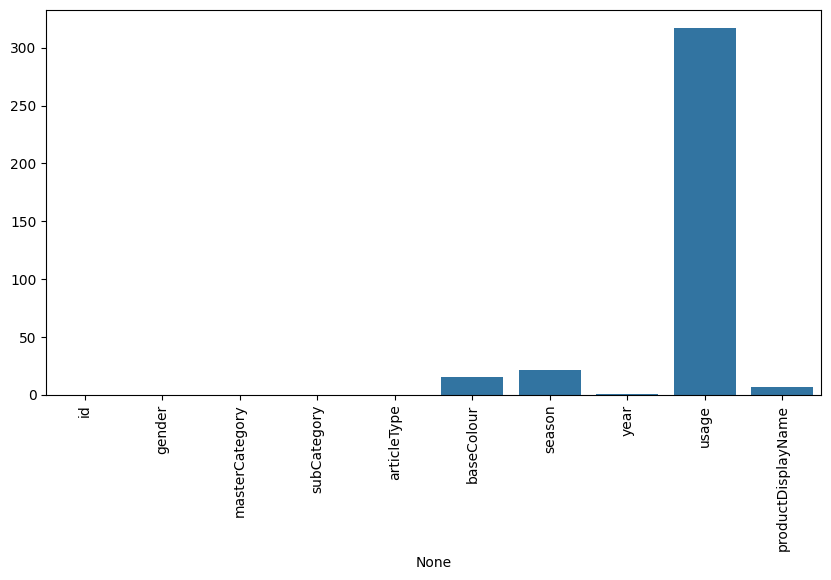

In [9]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=df.isnull().sum().index,
    y=df.isnull().sum().values
)

plt.xticks(rotation=90)
plt.show()

In [10]:
# Missing Value Treatment

# For categorical columns:

cat_cols=df.select_dtypes(include='object').columns


for col in cat_cols:
    df[col]=df[col].fillna("Unknown")

In [11]:
# Duplicate Handling

# Check duplicates:

df.duplicated().sum()

np.int64(0)

In [12]:
df=df.drop_duplicates()

df.shape

(44424, 10)

In [13]:
# mage Availability Check

# Images folder:

image_path = path+"/images"


image_files=os.listdir(image_path)

len(image_files)

44441

# Create Image Path Column

In [14]:
df["image_path"]=df["id"].astype(str)+".jpg"

df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,15970.jpg
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,39386.jpg
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,59263.jpg
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,21379.jpg
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,53759.jpg


# Check Missing Images

In [15]:
available=[]


for img in df["image_path"]:

    if img in image_files:
        available.append(True)
    else:
        available.append(False)


df["image_available"]=available

In [16]:
# Remove missing images:

df=df[df.image_available==True]

df.shape

(44419, 12)

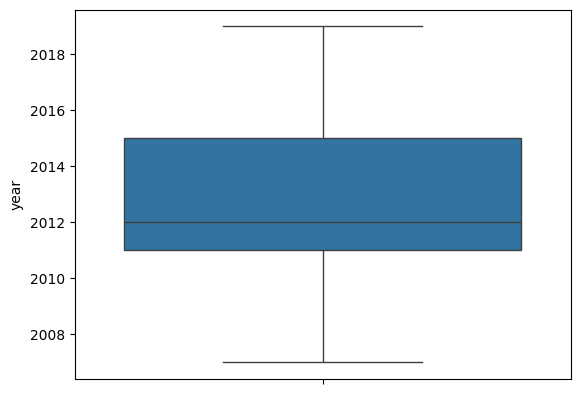

In [17]:
# Outlier Analysis

# For year:

sns.boxplot(df["year"])

plt.show()

In [18]:
df=df[
    (df["year"]>=2000)
    &
    (df["year"]<=2025)
]

In [21]:
df['year'].unique()

array([2011., 2012., 2016., 2017., 2015., 2014., 2010., 2013., 2018.,
       2019., 2007., 2009., 2008.])

In [22]:
# Feature Engineering

# Create combined category:

df["category"] = (
    df["masterCategory"]
    +"_"+
    df["subCategory"]
)

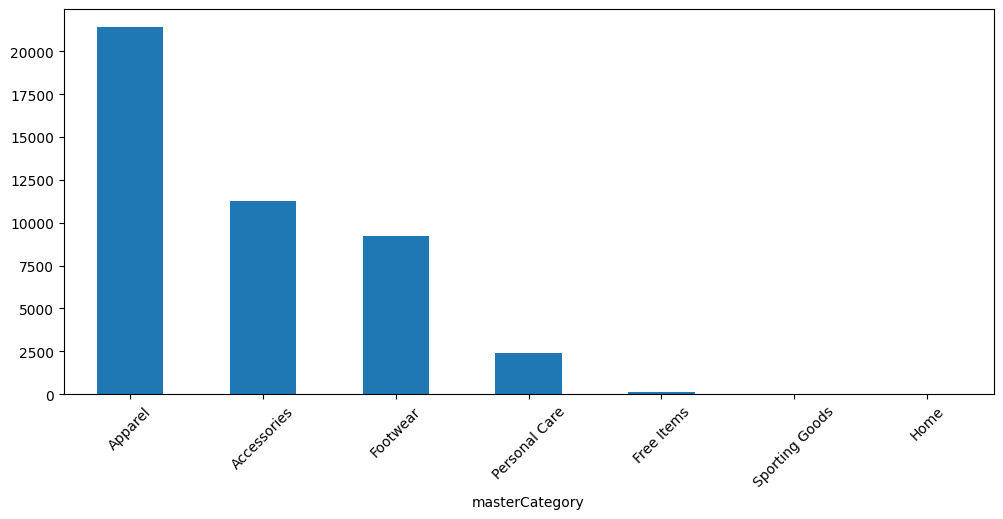

In [23]:
# Check Category Distribution
plt.figure(figsize=(12,5))


df["masterCategory"].value_counts().plot(
    kind="bar"
)


plt.xticks(rotation=45)

plt.show()

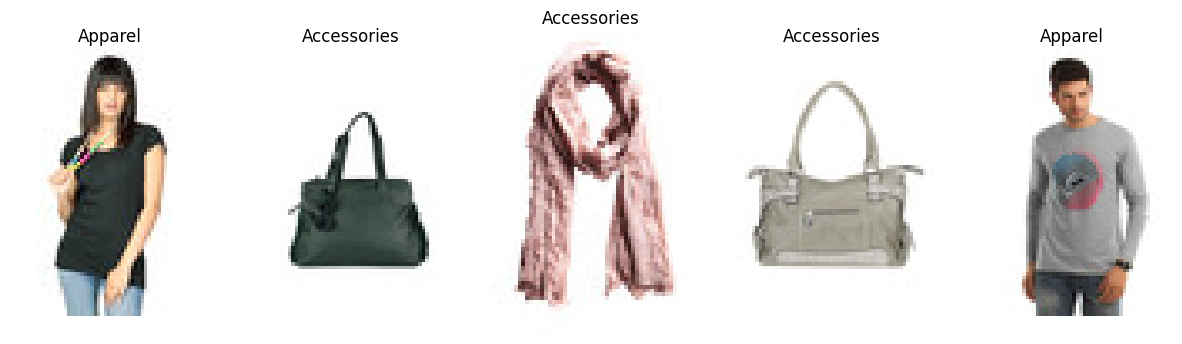

In [24]:
# Image Visualization
from PIL import Image


sample=df.sample(5)


plt.figure(figsize=(15,5))


for i,row in enumerate(sample.itertuples()):

    img=Image.open(
        image_path+"/"+row.image_path
    )


    plt.subplot(1,5,i+1)

    plt.imshow(img)

    plt.title(row.masterCategory)

    plt.axis("off")


plt.show()

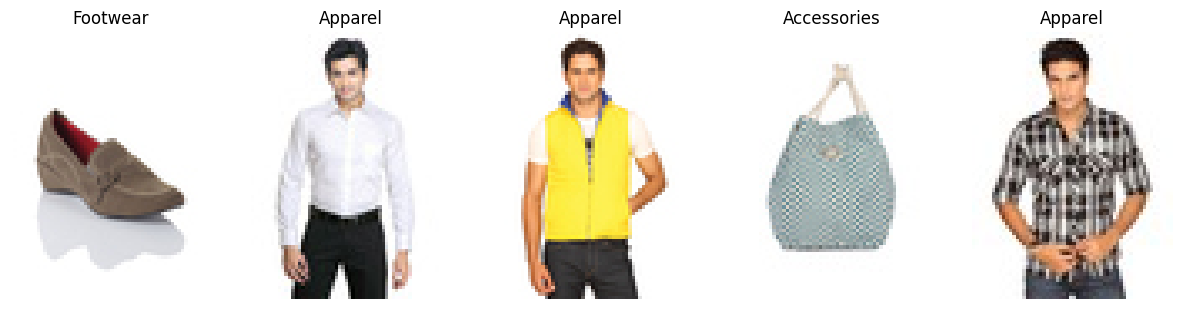

In [25]:
# Image Visualization
from PIL import Image


sample=df.sample(5)


plt.figure(figsize=(15,5))


for i,row in enumerate(sample.itertuples()):

    img=Image.open(
        image_path+"/"+row.image_path
    )


    plt.subplot(1,5,i+1)

    plt.imshow(img)

    plt.title(row.masterCategory)

    plt.axis("off")


plt.show()

In [27]:
# Correlation Analysis

# Convert categorical to numerical:

corr_df=df.copy()


corr_df=corr_df.select_dtypes(
    include=np.number
)


corr_df.corr()

,id,year
id,1.000000,0.415018
year,0.415018,1.000000


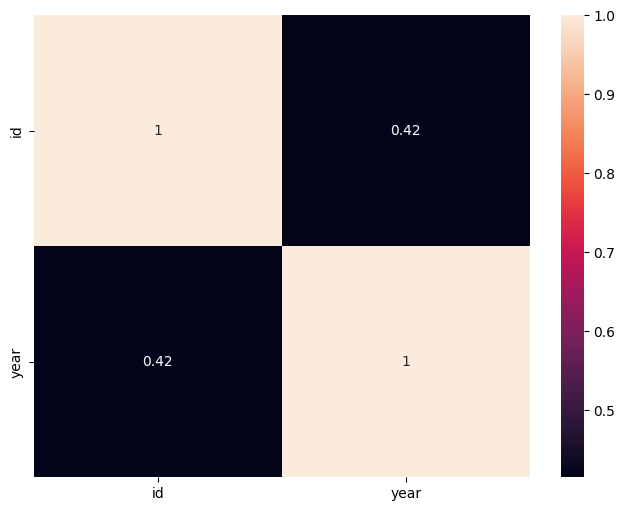

In [28]:
# Heatmap:

plt.figure(figsize=(8,6))


sns.heatmap(
    corr_df.corr(),
    annot=True
)


plt.show()

In [29]:
# Prepare Image Data

# Select main categories:

classes=df["masterCategory"].unique()

classes

array(['Apparel', 'Accessories', 'Footwear', 'Personal Care',
       'Free Items', 'Sporting Goods', 'Home'], dtype=object)

In [30]:
# Create generators:

datagen=ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [32]:
# Training Data

train_generator=datagen.flow_from_dataframe(

    dataframe=df,

    directory=image_path,

    x_col="image_path",

    y_col="masterCategory",

    target_size=(128,128),

    batch_size=32,

    class_mode="categorical",

    subset="training"

)

Found 35535 validated image filenames belonging to 7 classes.


In [33]:
# Validation Data

val_generator=datagen.flow_from_dataframe(

    dataframe=df,

    directory=image_path,

    x_col="image_path",

    y_col="masterCategory",

    target_size=(128,128),

    batch_size=32,

    class_mode="categorical",

    subset="validation"

)

Found 8883 validated image filenames belonging to 7 classes.


In [34]:
model=Sequential()


model.add(
Conv2D(
32,
(3,3),
activation="relu",
input_shape=(128,128,3)
)
)


model.add(MaxPooling2D())


model.add(
Conv2D(
64,
(3,3),
activation="relu"
)
)


model.add(MaxPooling2D())


model.add(Flatten())


model.add(
Dense(
128,
activation="relu"
)
)


model.add(
Dropout(0.5)
)


model.add(
Dense(
len(classes),
activation="softmax"
)
)



model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,223 (28.20 MB)

 Trainable params: 7,393,223 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Compile
model.compile(

optimizer="adam",

loss="categorical_crossentropy",

metrics=["accuracy"]

)

In [37]:
# Train Model
history=model.fit(

train_generator,

epochs=2,

validation_data=val_generator

)

Epoch 1/2
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 191s 172ms/step - accuracy: 0.9443 - loss: 0.1919 - val_accuracy: 0.9612 - val_loss: 0.1259
Epoch 2/2
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 63s 56ms/step - accuracy: 0.9634 - loss: 0.1323 - val_accuracy: 0.9721 - val_loss: 0.0974


In [38]:
# Performance Evaluation
# Accuracy
loss,accuracy=model.evaluate(val_generator)


print(
"Accuracy:",
accuracy
)

278/278 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - accuracy: 0.9721 - loss: 0.0974
Accuracy: 0.9720814824104309


In [39]:
# Classification Report
pred=model.predict(val_generator)


y_pred=np.argmax(pred,axis=1)


print(
classification_report(
val_generator.classes,
y_pred
)
)

278/278 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step
              precision    recall  f1-score   support

           0       0.26      0.26      0.26      2273
           1       0.48      0.48      0.48      4247
           2       0.21      0.21      0.21      1857
           3       0.00      0.00      0.00        21
           5       0.05      0.05      0.05       483
           6       0.00      0.00      0.00         2

    accuracy                           0.34      8883
   macro avg       0.17      0.17      0.17      8883
weighted avg       0.34      0.34      0.34      8883



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


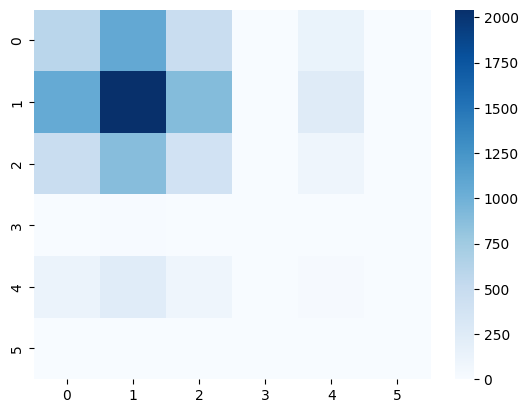

In [40]:
# Confusion Matrix
cm=confusion_matrix(
val_generator.classes,
y_pred
)


sns.heatmap(
cm,
cmap="Blues"
)

plt.show()

In [41]:
# Image Verification System

# Requirement:

# Flag unclear images for manual verification

# We can use image confidence.

# Example:

prediction=model.predict(
val_generator
)


confidence=np.max(
prediction,
axis=1
)


threshold=0.60


flagged=sum(
confidence<threshold
)


print(
"Images requiring manual review:",
flagged
)

278/278 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step
Images requiring manual review: 176
